# Question from CEO
### How much is our daily revenue by category?

In [2]:
import pandas as pd

# Getting products data only 5000 rows
df_products = pd.read_csv('../data/BaSalam.products.csv', nrows=5000)

df_products.head()

,_id,_score,sales_count_week,name,price,status_id,status_title,stock,photo_MEDIUM,photo_SMALL,...,vendor_owner_city,vendor_owner_id,isFreeShipping,IsAvailable,IsSaleable,mainAttribute,categoryTitle,published,video_ORIGINAL,promotions
0,9873883,468.75000,14,پسته فندقی خندان امسالی یک کیلویی تضمین کیفیت ...,5170000,2976,در دسترس,746,https://statics.basalam.com/public-17/users/Pe...,https://statics.basalam.com/public-17/users/Pe...,...,قاین,13052433,False,True,True,1000 گرم,میوه تازه,NaN,NaN,NaN
1,21808,466.66666,13,روغن زیتون فدک 1 لیتری مزرعه ارگانیک فدک سید ا...,6600000,2976,در دسترس,4,https://statics.basalam.com/public-3/users/J2/...,https://statics.basalam.com/public-3/users/J2/...,...,قم,20,False,True,True,900 گرم,روغن‌های خوراکی,True,https://basalam-com.arvanvod.ir/yOpvGE3e0D/x3Q...,NaN
2,10215970,464.28570,12,عناب درجه یک بیرجند یک کیلویی. تضمین کیفیت و ...,1360000,2976,در دسترس,813,https://statics.basalam.com/public-13/users/Pe...,https://statics.basalam.com/public-13/users/Pe...,...,قاین,13052433,False,True,True,1000 گرم,میوه تازه,NaN,NaN,NaN
3,11061637,461.53845,11,هل سبز اکبر بنفش50گرمی. سبز ودرشت وبسیار معطر,1054000,2976,در دسترس,1708,https://statics.basalam.com/public-14/users/ME...,https://statics.basalam.com/public-14/users/ME...,...,قاین,1145924,False,True,True,50 گرم,ادویه,NaN,NaN,NaN
4,10843522,461.53845,11,زرشک دانه اناری اعلا 1402(یک کیلویی).محصول تضم...,1830000,2976,در دسترس,1509,https://statics.basalam.com/public-16/users/LZ...,https://statics.basalam.com/public-16/users/LZ...,...,قاین,1246369,False,True,True,1000 گرم,میوه تازه,NaN,NaN,NaN


##  Converting Currency =>

In [3]:
# converting price currency from IRR to USD (1 USD = 1.500.000 IRR = 150.000 TOMAN )
df_products['price'] = ((df_products['price'] / 10) / 150000).round(2)
df_products['price']

0       3.45
1       4.40
2       0.91
3       0.70
4       1.22
        ... 
4995    1.40
4996    0.20
4997    0.60
4998    0.07
4999    1.87
Name: price, Length: 5000, dtype: float64

## Daily Revenue

In [4]:
daily_revenue = ((df_products['price'] * df_products['sales_count_week']) / 7)
daily_revenue.sum().round(2)

np.float64(872.89)

## Top 10 daily revenue category

In [5]:
df_products['daily_revenue'] = ((df_products['price'] * df_products['sales_count_week']) / 7)
top_ten = df_products.groupby('categoryTitle')['daily_revenue'].sum().sort_values(ascending=False).head(10)
top_ten

categoryTitle
روغن‌های خوراکی    73.141429
عسل                59.315714
برنج               58.982857
ادویه              48.580000
میوه خشک           42.722857
پسته               40.678571
قهوه               36.645714
چای                33.394286
آجیل               31.514286
میوه تازه          25.822857
Name: daily_revenue, dtype: float64

## Creating Bar_Chart for better visualization

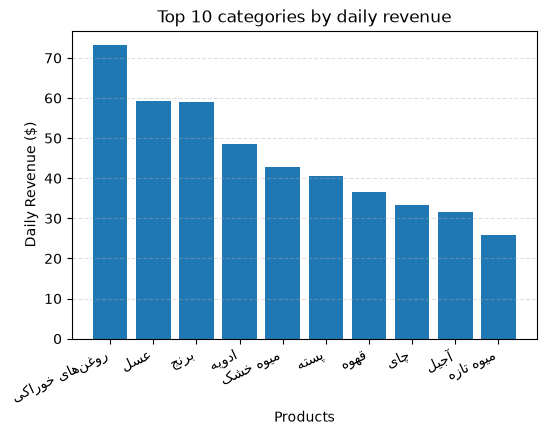

In [6]:
import matplotlib.pyplot as plt

# creating figure chart
plt.figure(figsize=(6,4))

# giving values to the chart
plt.bar(top_ten.index, top_ten.values)
plt.xticks(rotation=25, ha='right')
plt.xlabel('Products')
plt.ylabel('Daily Revenue ($)')

plt.title('Top 10 categories by daily revenue')
plt.grid(axis='y', ls='--', alpha=.4)

# saving chart pic to the outputs folder and showing the chart
plt.savefig('../outputs/daily_top_categories_revenue_01.png', bbox_inches='tight')
plt.show()

In [7]:
total = df_products['daily_revenue'].sum()
share = (top_ten / total * 100).round(1)
print(share)
print(f"Top 3 categories = {share.head(3).sum():.1f}% of revenue")

categoryTitle
روغن‌های خوراکی    8.4
عسل                6.8
برنج               6.8
ادویه              5.6
میوه خشک           4.9
پسته               4.7
قهوه               4.2
چای                3.8
آجیل               3.6
میوه تازه          3.0
Name: daily_revenue, dtype: float64
Top 3 categories = 22.0% of revenue


## Answer to CEO:
### The top 3 categories (1.oil, 2.honey, 3.rice) generate 22% of estimated daily revenue. Limitation: based on the top 5,000 products by score, not the full data.